In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd "/content/drive/MyDrive/Master's Thesis v0.4/TM Project/"

/content/drive/MyDrive/Master's Thesis v0.4/TM Project


In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
import devices
import models
import samplers
import trainers
import utils

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

In [ ]:
memory_type = torch.device('cpu')
dtype = torch.float32
num_modes = 1
study = 'TE'

In [ ]:
beta = 0.95

# device 1

In [ ]:
# parameters
lambd = 1.55

# wave number and normalized spacing
k_0 = 2 * np.pi / lambd

# device 1

# spacing
dx = 0.0952 * k_0
dy = 0.05 * k_0

# simulation lengths

core_length_x = 2 * k_0 # W
core_length_y = 1.1 * k_0 # H

substrate_length_x = 3.0 * k_0 # Xs
substrate_length_y = 5.025 * k_0 # Ys

rib_length = 0.2 * k_0 # D

cladding_length_y = 0.525 * k_0 # Yc

# refractive indices
n_core = 3.44
n_substrate = 3.34
n_cladding = 1

In [ ]:
weights = [1, n_substrate, 1, 1, n_substrate, n_substrate]
m = 4

In [ ]:
reference_device = devices.RibWaveguide(n_substrate, n_core, n_cladding, lambd, [substrate_length_x, core_length_x, substrate_length_x], [substrate_length_y, rib_length, core_length_y, cladding_length_y], study)

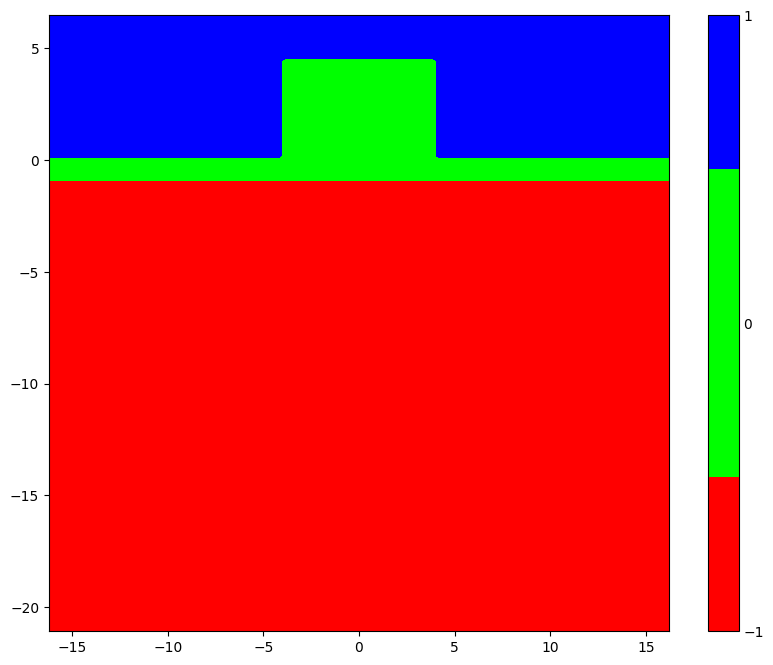

In [ ]:
reference_device.plot(dx, dy)

In [1]:
torch.manual_seed(42)
base_model = models.vanilla_network(2, 512, num_modes, 1, 'RBF')
# base_model = models.DDCN(reference_device, dx, dy, 2, 256, num_modes, 1, 'RBF')
optimizer = torch.optim.Adamax(base_model.parameters(), lr=3e-2)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[9000], gamma=1e-1)
print('number of trainable parameters', sum([p.numel() for p in base_model.parameters() if p.requires_grad]))

NameError: name 'torch' is not defined

In [ ]:
device = devices.RibWaveguideWithPINNs(n_substrate, n_core, n_cladding, lambd, [substrate_length_x, core_length_x, substrate_length_x], [substrate_length_y, rib_length, core_length_y, cladding_length_y], study, base_model, 1, False)

In [ ]:
# xy = samplers.uniform_grid_2d(device, dx, dy, dtype, memory_type)
# features = base_model.make_features(xy)


In [ ]:
# plt.figure(figsize=(10, 10))
# plt.scatter(xy[:, 0].cpu().detach(), xy[:, 1].cpu().detach(), c= features[:, 1].cpu(), s=1)
# plt.scatter(xy[left_bd_indices, 0].cpu().detach(), xy[left_bd_indices, 1].cpu().detach(), c= 'black', s=1)
# plt.vlines(x = core_length_x/2, ymin = 0, ymax=core_length_y, color='r', linewidth=1)
# plt.vlines(x = 0, ymin = 0, ymax=core_length_y, color='r', linewidth=1)

In [ ]:
reference_device_fd = devices.RibWaveguideWithFD(n_substrate, n_core, n_cladding, lambd, [substrate_length_x, core_length_x, substrate_length_x], [substrate_length_y, rib_length, core_length_y, cladding_length_y], study, dx, dy)

In [ ]:
base_model.to(memory_type)
dummy_optim = torch.optim.Adamax(base_model.parameters(), lr=1e-2)
xy_dummy = torch.rand(2048, 2).to(memory_type)*2-1
xy_dummy[:, :2] *= 10
example_fun = torch.exp(-(xy_dummy[:, 0]**2+xy_dummy[:, 1]**2)/10)*2
example_fun = example_fun.unsqueeze(1)
for i in range(1000):
  optimizer.zero_grad()
  u = base_model(xy_dummy)
  loss = torch.mean((u-example_fun)**2)
  base_model.zero_grad()
  loss.backward()
  optimizer.step()
dummy_optim.zero_grad()
print(loss.item())

4.648122194339521e-05


In [ ]:
train_agent = trainers.Trainer2D(dtype, device, reference_device_fd, memory_type, samplers.uniform_grid_2d, optimizer, scheduler, dx=dx, dy=dy, num_samples=None, n_lower=None, n_upper=None, beta=beta)

  0%|          | 0/10001 [00:00<?, ?it/s]

num samples 5891


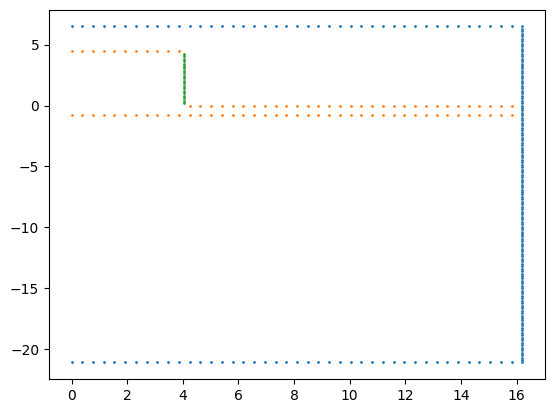

loss1 is 1.17282, loss2 is 0.2368, loss3 is 1.857, loss4 is 0.0, loss5 is 0.05157, loss6 is 0.39268, total loss 1.6170677542686462, eigen value 3.366909927291803:   0%|          | 0/10001 [00:00<?, ?it/s]

3.366909927291803 11.336082458496094
1.2315860192957717 1.516804122924805


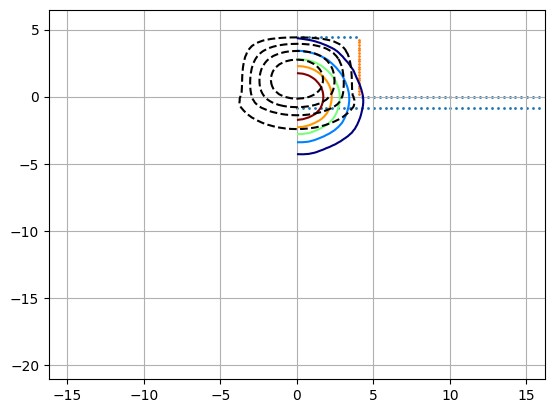

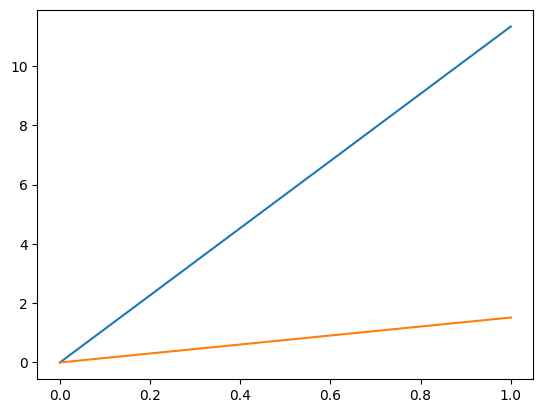

loss1 is 0.09112, loss2 is 0.00279, loss3 is 1.59976, loss4 is 0.0, loss5 is 0.01138, loss6 is 0.15801, total loss 0.26051127910614014, eigen value 3.3766026400501947:   1%|          | 100/10001 [00:48<1:10:23,  2.34it/s]

3.3766026400501947 11.401445388793945
3.368162099614153 11.344515929277218


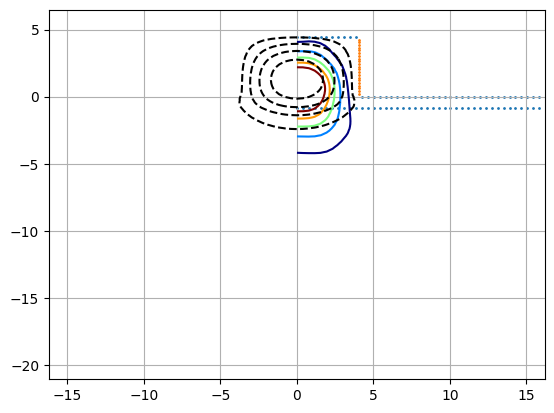

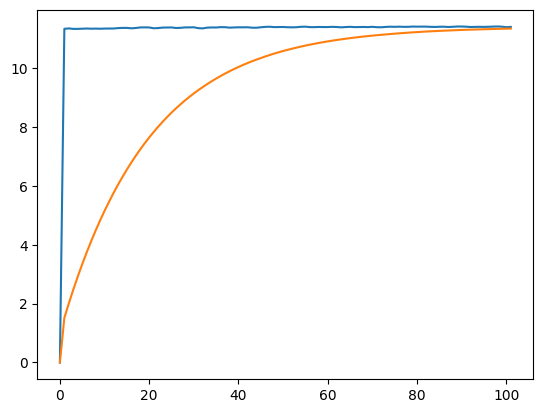

loss1 is 0.09458, loss2 is 0.0002, loss3 is 1.45741, loss4 is 0.0, loss5 is 0.01031, loss6 is 0.16935, total loss 0.27424201369285583, eigen value 3.383420259708893:   2%|▏         | 200/10001 [01:34<1:17:26,  2.11it/s]

3.383420259708893 11.447532653808594
3.3815158500375757 11.43464944405535


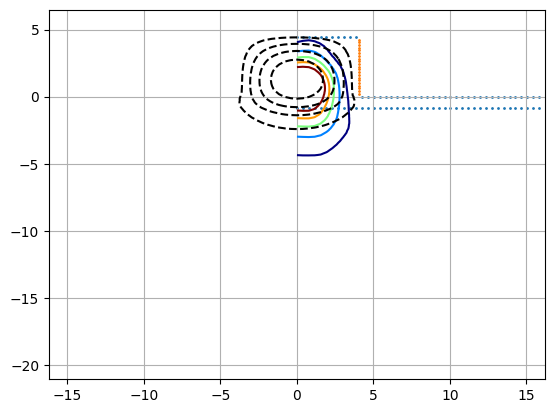

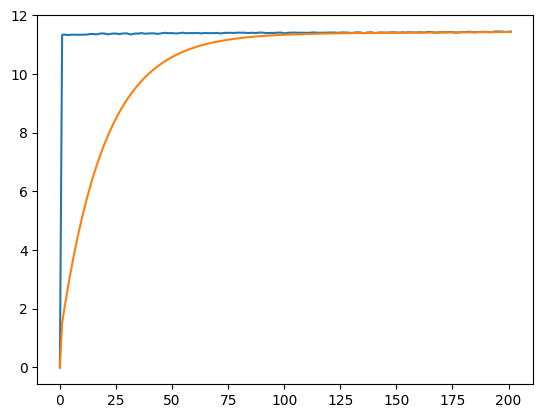

loss1 is 0.16507, loss2 is 0.00969, loss3 is 0.96323, loss4 is 0.0, loss5 is 0.00851, loss6 is 0.11644, total loss 0.29002178460359573, eigen value 3.4224637017230464:   3%|▎         | 300/10001 [02:19<1:09:01,  2.34it/s]

3.4224637017230464 11.713257789611816
3.4074104710464677 11.61044611819711


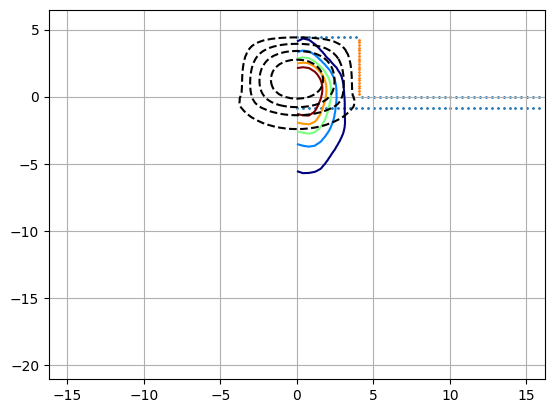

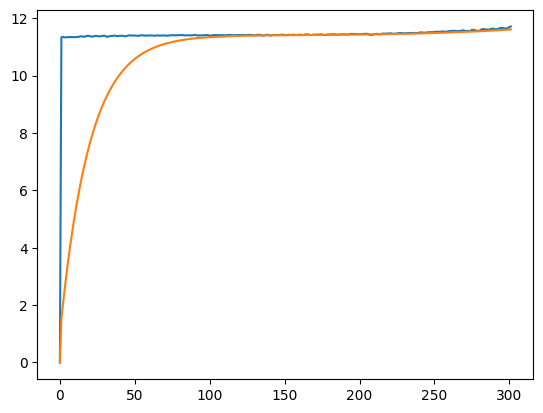

loss1 is 0.26417, loss2 is 0.02242, loss3 is 0.83867, loss4 is 0.0, loss5 is 0.01859, loss6 is 0.15199, total loss 0.43474744260311127, eigen value 3.44095729016707:   4%|▎         | 375/10001 [02:52<1:08:49,  2.33it/s]

In [ ]:
loss_history, rayleigh_history, mode_errors_list = train_agent.train(10001, num_modes, weights=weights, m=m, verbose=10, calc_error=False, plot_solution=True, sample_new=False)

In [ ]:
base_model.to('cpu')

In [ ]:
yu = torch.arange(0, reference_device.upward_length, dy, dtype=dtype, device=memory_type).reshape(-1, 1)
end_val_yu = yu[-1]
yb = torch.arange(0, reference_device.downward_length, dy, dtype=dtype, device=memory_type).reshape(-1, 1)
end_val_yb = yb[-1]
xy = torch.cat((torch.flip(-yb, dims=(0,))[:-1], yu))

xy = torch.cat((torch.full_like(xy, 0), xy), dim=-1)
# if device.augmented_input:
#   xy = torch.cat((xy, (1/reference_device.regions(xy, format='torch').view(-1, 1))), dim=-1)
u = base_model.forward_with_features(xy.cpu()).cpu()

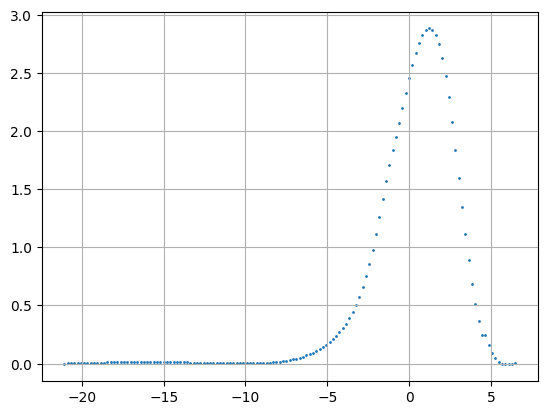

In [ ]:
plt.scatter(xy[:, 1].cpu().detach(), u[:, 0].detach().numpy(), s=1)
plt.grid()

In [ ]:
xy = torch.arange(-device.total_length_x/2, device.total_length_x/2, step=dx/2, device=memory_type).reshape(-1, 1)
xy = torch.cat((xy, torch.full_like(xy, 2*dx)), dim=-1)
# if device.augmented_input:
  # xy = torch.cat((xy, (1/reference_device.regions(xy, format='torch').view(-1, 1))), dim=-1)
u = base_model.forward_with_features(xy.cpu()).cpu()

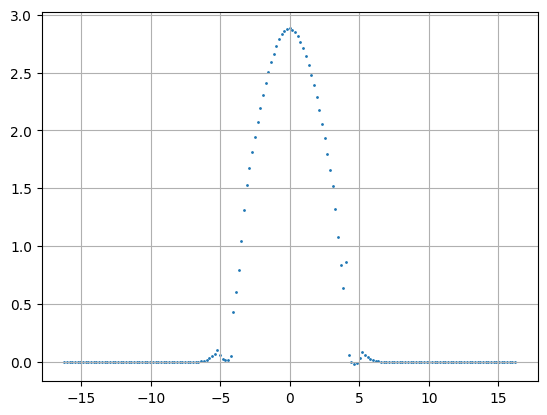

In [ ]:
plt.scatter(xy[:, 0].cpu().detach(), u[:, 0].detach().numpy(), s=1)
plt.grid()

In [ ]:
RI_squared, xy_fd, u_fd = reference_device_fd.evaluate()
xy_fd = torch.from_numpy(xy_fd).to(torch.float32)
xy = torch.cat((xy_fd, (1/reference_device.regions(xy_fd, format='torch').view(-1, 1))), dim=-1)
u = base_model(xy.cpu())
u = u/torch.linalg.norm(u, dim=0, keepdims=True)
print(np.sqrt(RI_squared))

[3.39083654]


In [ ]:
u = u/torch.linalg.norm(u, dim=0, keepdims=True)/np.max(u_fd)
u_fd = u_fd/np.max(u_fd)

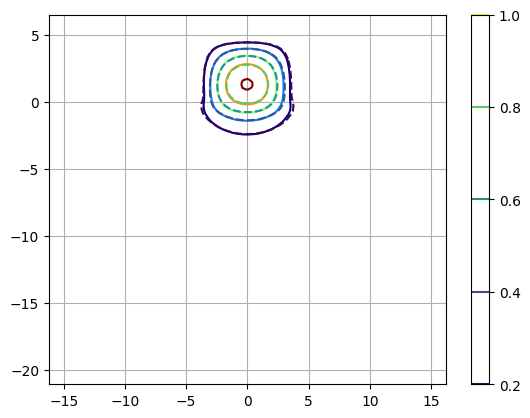

In [ ]:
levels = np.linspace(0, np.max(u_fd), 6)[1:]
plt.tricontour(xy[:, 0].cpu().detach(), xy[:, 1].detach().cpu(), u[:,0].detach(), levels=levels, cmap='jet')
plt.tricontour(xy_fd[:, 0], xy_fd[:, 1], u_fd[:,0], linestyles='dashed', levels=levels)
plt.colorbar()
plt.grid()

# device 2

In [ ]:
# parameters
lambd = 1.55

# wave number and normalized spacing
k_0 = 2 * np.pi / lambd

# device 2

#spacing
dx = 0.0968 * k_0
dy =  0.05 * k_0

# simulation lengths

core_length_x = 3 * k_0 # W
core_length_y = 0.1 * k_0 # H

substrate_length_x = 3.05 * k_0 # Xs
substrate_length_y = 5.025 * k_0 # Ys

rib_length = 0.9 * k_0 # D

cladding_length_y = 0.525 * k_0 # Yc

# refractive indices
n_core = 3.44
n_substrate = 3.36
n_cladding = 1

In [ ]:
weights = [n_substrate, np.sqrt(n_substrate), 1, 1, n_substrate, 1]
m = 2

In [ ]:
reference_device = devices.RibWaveguide(n_substrate, n_core, n_cladding, lambd, [substrate_length_x, core_length_x, substrate_length_x], [substrate_length_y, rib_length, core_length_y, cladding_length_y], study)

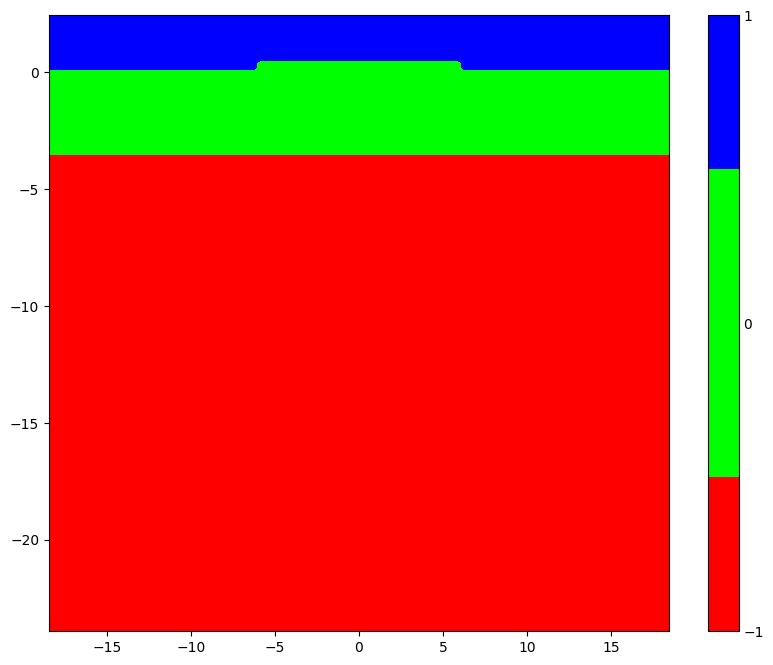

In [ ]:
reference_device.plot(dx, dy)

In [ ]:
torch.manual_seed(42)
base_model = models.discontinuity_capturing_network(2, 512, num_modes, 1, 'DRBF')
optimizer = torch.optim.Adamax(base_model.parameters(), lr=3e-2)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[9000], gamma=1e-1)
print('number of trainable parameters', sum([p.numel() for p in base_model.parameters() if p.requires_grad]))

number of trainable parameters 3073


In [ ]:
device = devices.RibWaveguideWithPINNs(n_substrate, n_core, n_cladding, lambd, [substrate_length_x, core_length_x, substrate_length_x], [substrate_length_y, rib_length, core_length_y, cladding_length_y], study, base_model, True)

In [ ]:
reference_device_fd = devices.RibWaveguideWithFD(n_substrate, n_core, n_cladding, lambd, [substrate_length_x, core_length_x, substrate_length_x], [substrate_length_y, rib_length, core_length_y, cladding_length_y], study, dx, dy)

In [ ]:
base_model.to(memory_type)
dummy_optim = torch.optim.Adamax(base_model.parameters(), lr=1e-2)
xy_dummy = torch.rand(2048, 3).to(memory_type)*2-1
xy_dummy[:, :2] *= 10
example_fun = torch.exp(-(xy_dummy[:, 0]**2+xy_dummy[:, 1]**2)/10)*2
example_fun = example_fun.unsqueeze(1)
for i in range(1000):
  optimizer.zero_grad()
  u = base_model(xy_dummy)
  loss = torch.mean((u-example_fun)**2)
  base_model.zero_grad()
  loss.backward()
  optimizer.step()
dummy_optim.zero_grad()
print(loss.item())

5.3070366448082495e-06


In [ ]:
train_agent = trainers.Trainer2D(dtype, device, reference_device_fd, memory_type, samplers.uniform_grid_2d, optimizer, scheduler, dx=dx, dy=dy, num_samples=None, n_lower=None, n_upper=None, beta=beta)

num samples 12445


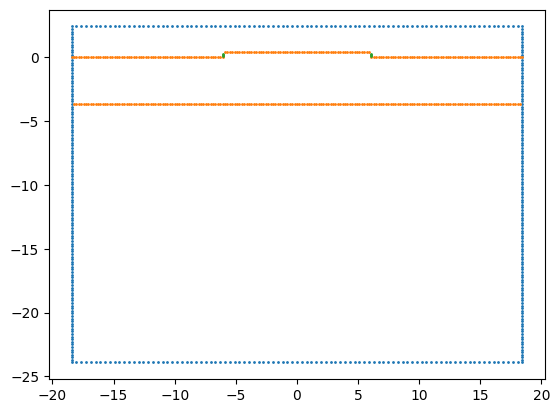

iteration 1 loss1 is 1.16773, loss2 is 0.43916, loss3 is 35.46087, loss4 is 0.0, loss5 is 0.14395, loss6 is 0.07353, total loss 1.3852169811725616
2.8438821279830373 8.087665557861328
1.1637797377051495 1.3543832778930667


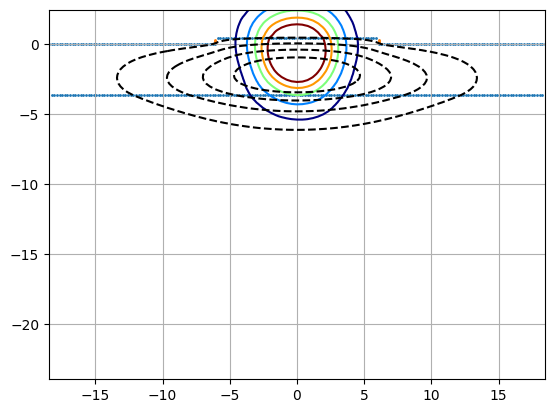

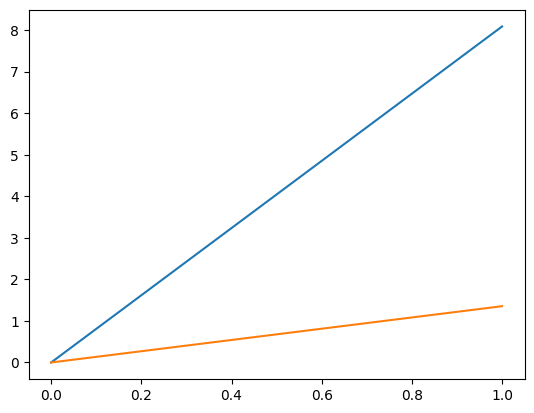

approaching the eigenvalue at 3.393438481598503 in iteration 183
upper and lower bounds: 3.44 3.36
tightened to: 3.402656115289351 3.388540443821522
current learning rate 0.03
learning rate reduced to 0.003
eigen value fixed at 3.394897859588982 in iteration 611
upper and lower bounds: 3.402656115289351 3.388540443821522
tightened to: 3.396524686350859 3.3939781686931476
current learning rate 0.003
learning rate reduced to 0.001
iteration 1001 loss1 is 0.02356, loss2 is 0.00016, loss3 is 2.34373, loss4 is 0.0, loss5 is 0.00055, loss6 is 0.00389, total loss 0.027999209705740213
3.3949204760579184 11.525485038757324
3.3949025704486027 11.525363462838529


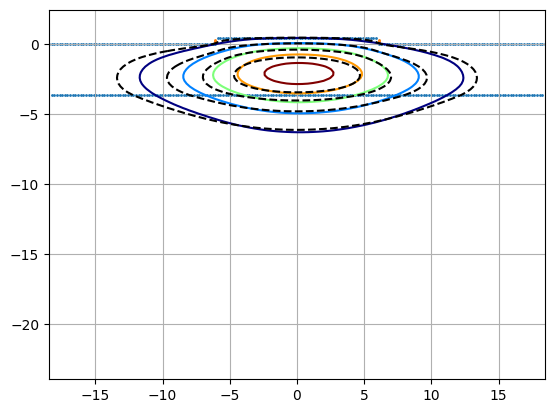

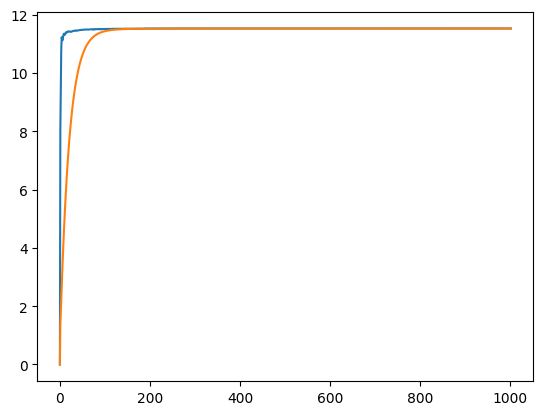

iteration 2001 loss1 is 0.02205, loss2 is 0.00012, loss3 is 2.34357, loss4 is 0.0, loss5 is 0.00057, loss6 is 0.0036, total loss 0.026213221717625856
3.3949284820439676 11.52553939819336
3.394916189262955 11.525455932119703


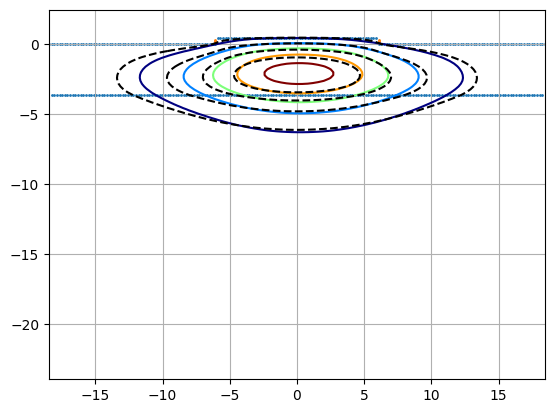

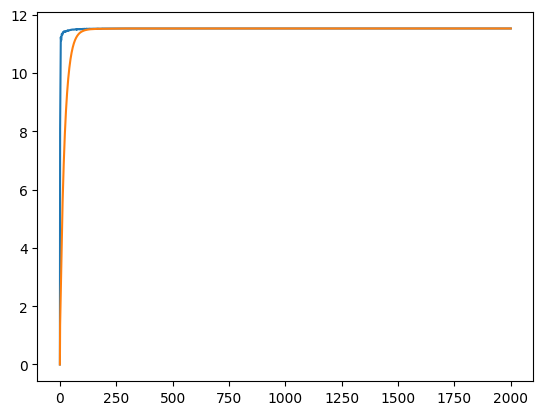

iteration 3001 loss1 is 0.02125, loss2 is 0.00012, loss3 is 2.3429, loss4 is 0.0, loss5 is 0.00052, loss6 is 0.00499, total loss 0.02675954205915332
3.3949614889800612 11.525763511657715
3.3949355347152013 11.52558728487199


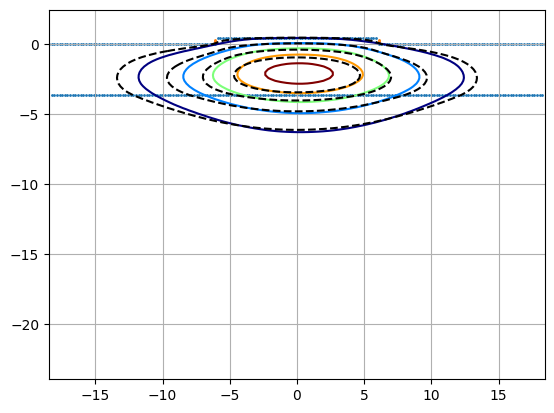

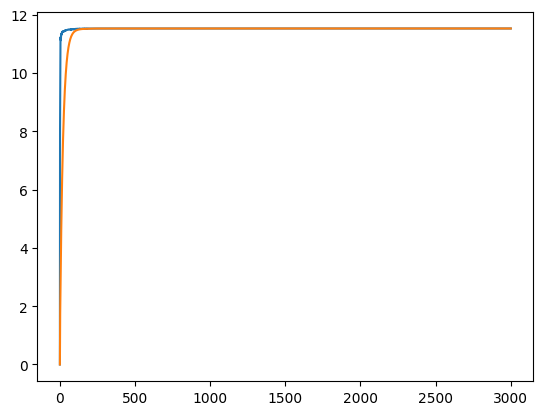

iteration 4001 loss1 is 0.02089, loss2 is 0.0001, loss3 is 2.34227, loss4 is 0.0, loss5 is 0.00053, loss6 is 0.00414, total loss 0.025558815337717533
3.3949923887996163 11.525973320007324
3.3949636414459747 11.525778126740112


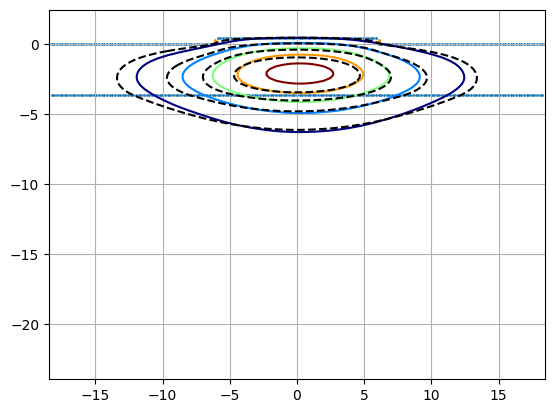

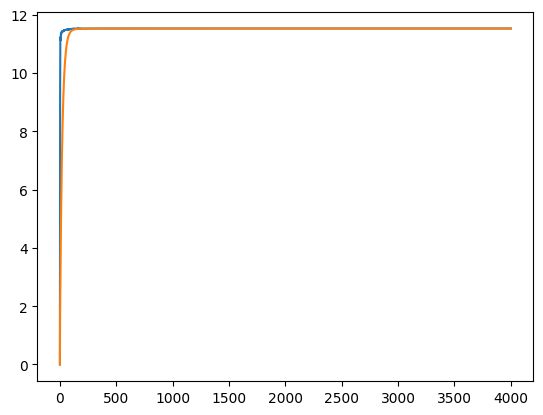

iteration 5001 loss1 is 0.02018, loss2 is 0.00011, loss3 is 2.34176, loss4 is 0.0, loss5 is 0.00048, loss6 is 0.00303, total loss 0.023694734321907163
3.395017389356886 11.526143074035645
3.3949911571605367 11.525964957198239


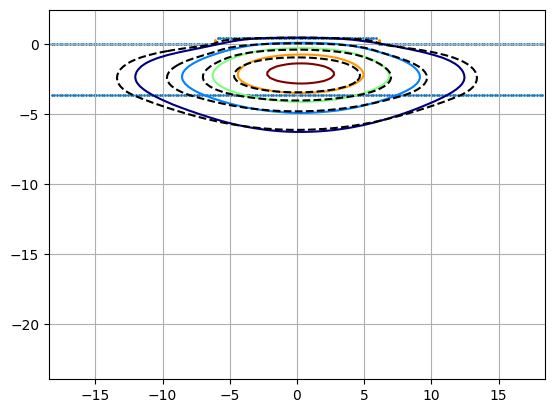

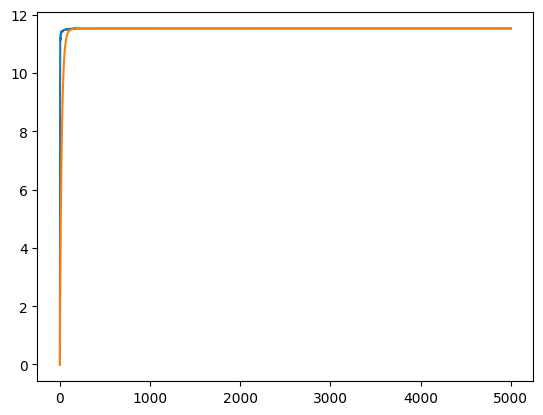

iteration 6001 loss1 is 0.02001, loss2 is 0.0001, loss3 is 2.34156, loss4 is 0.0, loss5 is 0.00065, loss6 is 0.00439, total loss 0.025050881784409285
3.3950270805346277 11.526208877563477
3.3950144787993533 11.526123311257244


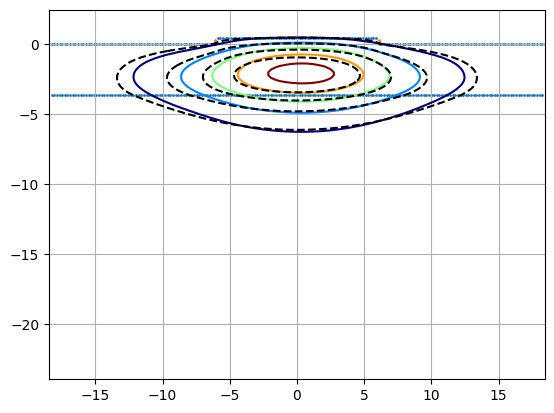

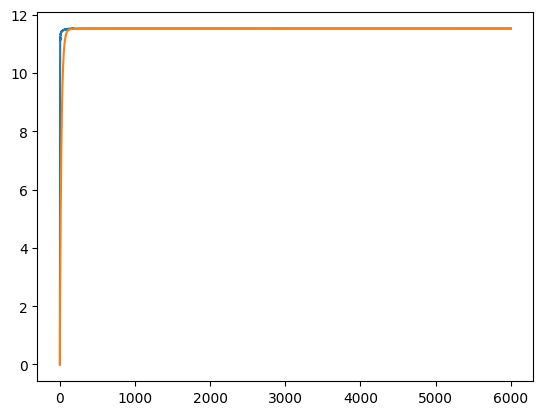

iteration 7001 loss1 is 0.01953, loss2 is 0.0001, loss3 is 2.34137, loss4 is 0.0, loss5 is 0.0005, loss6 is 0.00376, total loss 0.023781525902450085
3.3950362098796596 11.526270866394043
3.3950276236959493 11.526212565658565


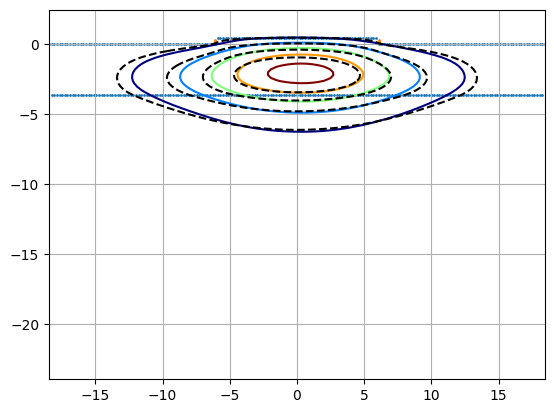

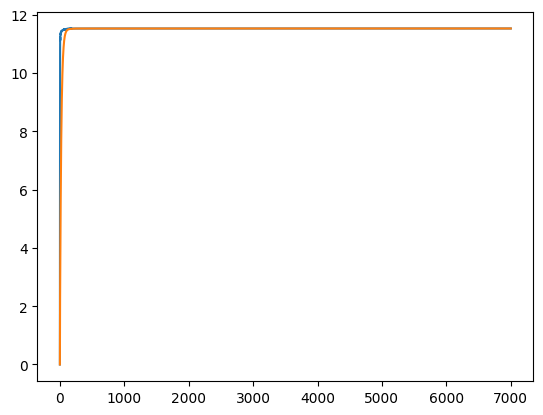

iteration 8001 loss1 is 0.01938, loss2 is 0.0001, loss3 is 2.34137, loss4 is 0.0, loss5 is 0.0006, loss6 is 0.00181, total loss 0.021796609507873654
3.395036490782194 11.526272773742676
3.3950337467303453 11.526254141437885


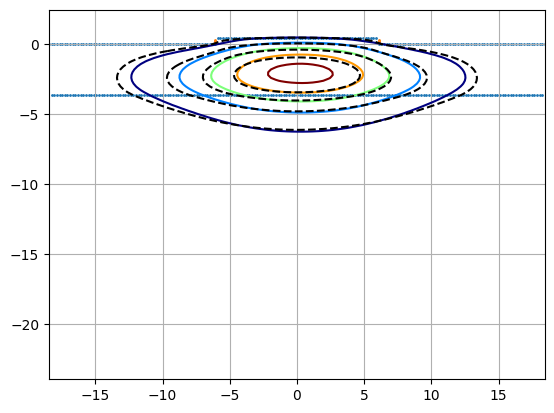

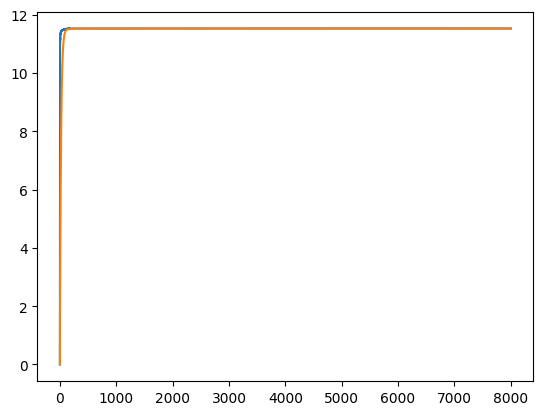

iteration 9001 loss1 is 0.01903, loss2 is 9e-05, loss3 is 2.34126, loss4 is 0.0, loss5 is 0.00051, loss6 is 0.00383, total loss 0.023370093200355768
3.395041827925939 11.5263090133667
3.395037165868456 11.526277357628118


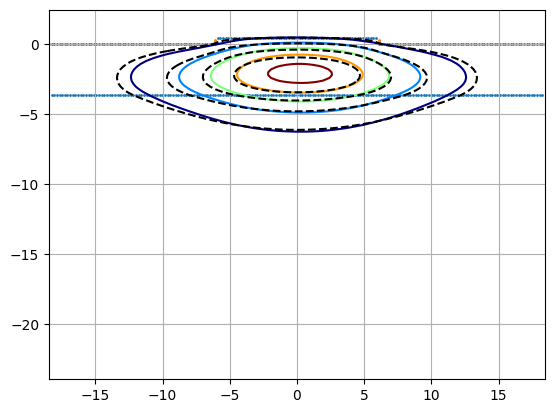

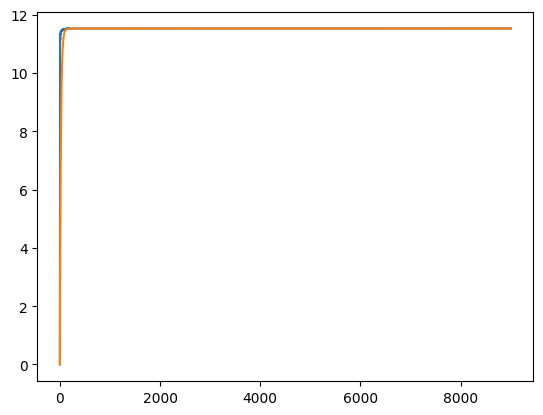

iteration 10001 loss1 is 0.01878, loss2 is 9e-05, loss3 is 2.34137, loss4 is 0.0, loss5 is 0.00016, loss6 is 0.00134, total loss 0.020277287694625556
3.3950362098796596 11.526270866394043
3.3950367738377825 11.526274695710857


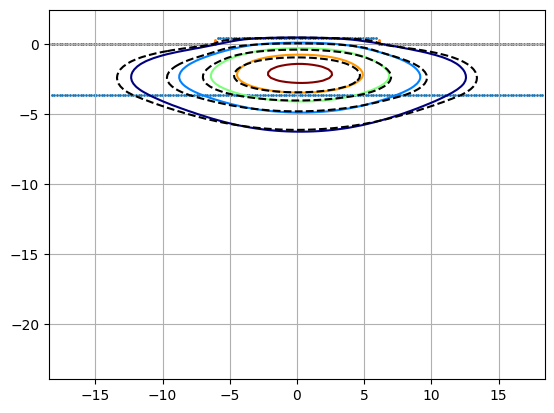

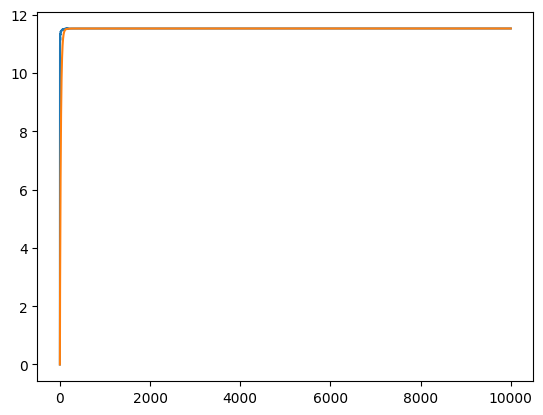

In [ ]:
loss_history, rayleigh_history, mode_errors_list = train_agent.train(10001, num_modes, weights=weights, m=m, verbose=1, calc_error=False, plot_solution=True, sample_new=False)

In [ ]:
base_model.to('cpu')

Sequential(
  (0): Linear(in_features=3, out_features=512, bias=True)
  (1): DRBF()
  (2): Linear(in_features=512, out_features=1, bias=True)
)

In [ ]:
yu = torch.arange(0, reference_device.upward_length, dy, dtype=dtype, device=memory_type).reshape(-1, 1)
end_val_yu = yu[-1]
yb = torch.arange(0, reference_device.downward_length, dy, dtype=dtype, device=memory_type).reshape(-1, 1)
end_val_yb = yb[-1]
xy = torch.cat((torch.flip(-yb, dims=(0,))[:-1], yu))

xy = torch.cat((torch.full_like(xy, dx), xy), dim=-1)
if device.augmented_input:
  xy = torch.cat((xy, 1/ reference_device.regions(xy, format='torch').view(-1, 1)), dim=-1)
u = base_model(xy.cpu()).cpu()

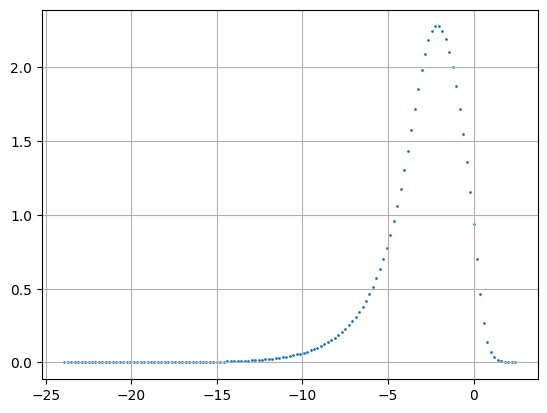

In [ ]:
plt.scatter(xy[:, 1].cpu().detach(), u[:, 0].detach().numpy(), s=1)
plt.grid()

In [ ]:
xy = torch.arange(-device.total_length_x/2, device.total_length_x/2, step=dx/2, device=memory_type).reshape(-1, 1)
xy = torch.cat((xy, torch.full_like(xy, dx)), dim=-1)
if device.augmented_input:
  xy = torch.cat((xy[:], 1/device.regions(xy, format='torch').view(-1, 1)), dim=-1)
u = base_model(xy.cpu()).cpu()

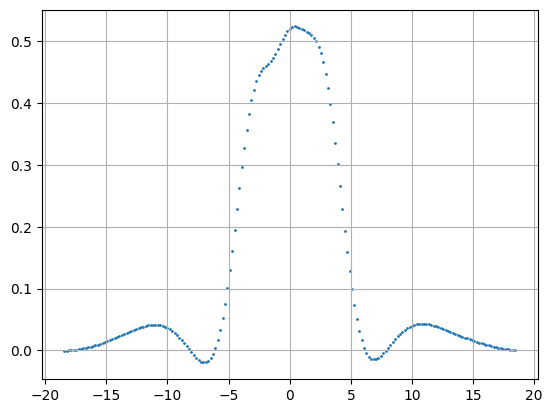

In [ ]:
plt.scatter(xy[:, 0].cpu().detach(), u[:, 0].detach().numpy(), s=1)
plt.grid()

In [ ]:
reference_device_fd = devices.RibWaveguideWithFD(n_substrate, n_core, n_cladding, lambd, [substrate_length_x, core_length_x, substrate_length_x], [substrate_length_y, rib_length, core_length_y, cladding_length_y], study, dx/4, dy/4, num_modes=2)

In [ ]:
RI_squared, xy_fd, u_fd = reference_device_fd.evaluate()
xy_fd = torch.from_numpy(xy_fd).to(torch.float32)
xy = torch.cat((xy_fd, device.regions(xy_fd, format='torch')), dim=-1)
u = base_model(xy.cpu())
u = u/torch.linalg.norm(u, dim=0, keepdims=True)
print(np.sqrt(RI_squared))

[3.39588581 3.38993084]


In [ ]:
u = u/torch.linalg.norm(u, dim=0, keepdims=True)/np.max(u_fd)
u_fd = u_fd/np.max(u_fd)

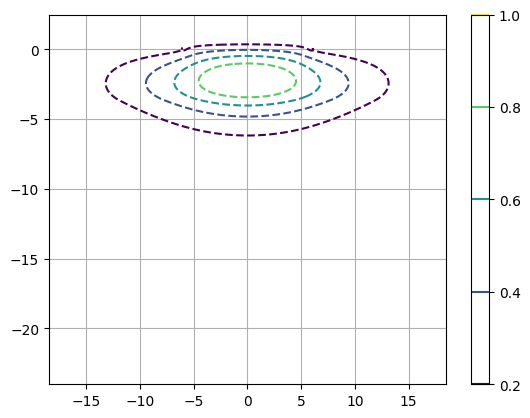

In [ ]:
levels = np.linspace(0, 1, 6)[1:]
# plt.tricontour(xy[:, 0].cpu().detach(), xy[:, 1].detach().cpu(), u[:,0].detach(), levels=levels, cmap='jet')
plt.tricontour(xy_fd[:, 0], xy_fd[:, 1], u_fd[:,0], linestyles='dashed', levels=levels)
plt.colorbar()
plt.grid()

# device 3

In [ ]:
# parameters
lambd = 1.55

# wave number and normalized spacing
k_0 = 2 * np.pi / lambd

# device 3 is done for both scalar and TM
# device 3
#spacing
dx = 0.0976 * k_0
dy =  0.1 * k_0

# simulation lengths

core_length_x = 4 * k_0 # W
core_length_y = 2.5 * k_0 # H

substrate_length_x = 4.34 * k_0 # Xs
substrate_length_y = 7.550 * k_0 # Ys

rib_length = 3.5 * k_0 # D

cladding_length_y = 0.55 * k_0 # Yc

# refractive indices
n_core = 3.44
n_substrate = 3.435
n_cladding = 1

In [ ]:
weights = [n_substrate, np.sqrt(n_substrate), 1, 1, n_substrate, 1]
m = 4

In [ ]:
reference_device = devices.RibWaveguide(n_substrate, n_core, n_cladding, lambd, [substrate_length_x, core_length_x, substrate_length_x], [substrate_length_y, rib_length, core_length_y, cladding_length_y], study)

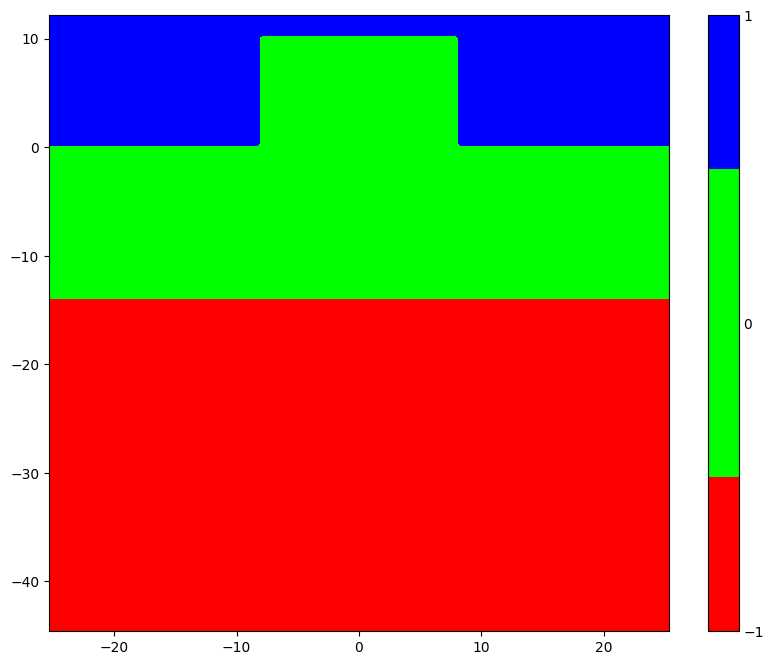

In [ ]:
reference_device.plot(dx, dy)

In [ ]:
torch.manual_seed(42)
base_model = models.discontinuity_capturing_network(2, 512, num_modes, 1, 'DRBF')
optimizer = torch.optim.Adamax(base_model.parameters(), lr=1e-2)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[9000], gamma=1e-1)
print('number of trainable parameters', sum([p.numel() for p in base_model.parameters() if p.requires_grad]))

number of trainable parameters 3073


In [ ]:
device = devices.RibWaveguideWithPINNs(n_substrate, n_core, n_cladding, lambd, [substrate_length_x, core_length_x, substrate_length_x], [substrate_length_y, rib_length, core_length_y, cladding_length_y], study, base_model, True)

In [ ]:
reference_device_fd = devices.RibWaveguideWithFD(n_substrate, n_core, n_cladding, lambd, [substrate_length_x, core_length_x, substrate_length_x], [substrate_length_y, rib_length, core_length_y, cladding_length_y], study, dx, dy)

In [ ]:
base_model.to(memory_type)
dummy_optim = torch.optim.Adamax(base_model.parameters(), lr=1e-2)
xy_dummy = torch.rand(2048, 3).to(memory_type)*2-1
xy_dummy[:, :2] *= 10
example_fun = torch.exp(-(xy_dummy[:, 0]**2+xy_dummy[:, 1]**2)/20)*15
example_fun = example_fun.unsqueeze(1)
for i in range(1000):
  optimizer.zero_grad()
  u = base_model(xy_dummy)
  loss = torch.mean((u-example_fun)**2)
  base_model.zero_grad()
  loss.backward()
  optimizer.step()
dummy_optim.zero_grad()
print(loss.item())

0.0002561389992479235


In [ ]:
train_agent = trainers.Trainer2D(dtype, device, reference_device_fd, memory_type, samplers.uniform_grid_2d, optimizer, scheduler, dx=dx, dy=dy, num_samples=None, n_lower=None, n_upper=None, beta=beta)

num samples 18189


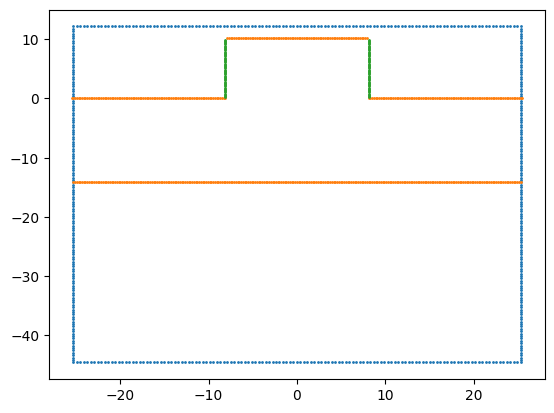

iteration 1 loss1 is 5.89788, loss2 is 0.01434, loss3 is 1.31325, loss4 is 0.0, loss5 is 0.35158, loss6 is 0.53981, total loss 6.789269328117371
3.4124344145232817 11.644708633422852
1.2378349775600717 1.532235431671143


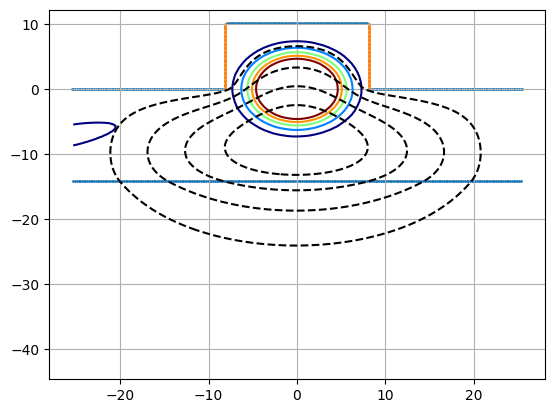

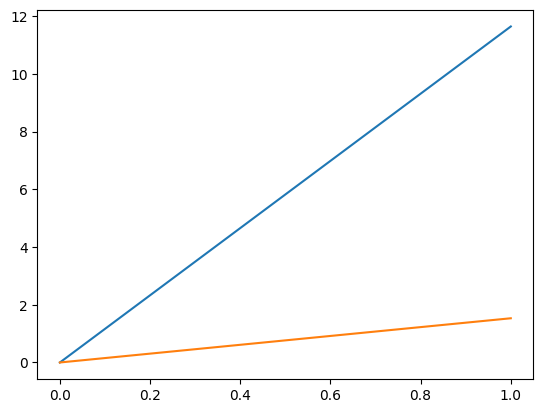

approaching the eigenvalue at 3.436392172116491 in iteration 417
upper and lower bounds: 3.44 3.435
tightened to: 3.4369827512725384 3.436158052492571
current learning rate 0.01
learning rate reduced to 0.001


In [ ]:
loss_history, rayleigh_history, mode_errors_list = train_agent.train(3001, num_modes, weights=weights, m=m, verbose=1, calc_error=False, plot_solution=True, sample_new=False)

In [ ]:
base_model.to('cpu')

In [ ]:
yu = torch.arange(0, reference_device.upward_length, dy, dtype=dtype, device=memory_type).reshape(-1, 1)
end_val_yu = yu[-1]
yb = torch.arange(0, reference_device.downward_length, dy, dtype=dtype, device=memory_type).reshape(-1, 1)
end_val_yb = yb[-1]
xy = torch.cat((torch.flip(-yb, dims=(0,))[:-1], yu))

xy = torch.cat((torch.full_like(xy, dx), xy), dim=-1)
if device.augmented_input:
  xy = torch.cat((xy, reference_device.regions(xy, format='torch').view(-1, 1)), dim=-1)
u = base_model(xy.cpu()).cpu()

In [ ]:
plt.scatter(xy[:, 1].cpu().detach(), u[:, 0].detach().numpy(), s=1)
plt.grid()

In [ ]:
xy = torch.arange(-device.total_length_x/2, device.total_length_x/2, step=dx, device=memory_type).reshape(-1, 1)
xy = torch.cat((xy, torch.full_like(xy, dx)), dim=-1)
if device.augmented_input:
  xy = torch.cat((xy[:], device.regions(xy, format='torch').view(-1, 1)), dim=-1)
u = base_model(xy.cpu()).cpu()

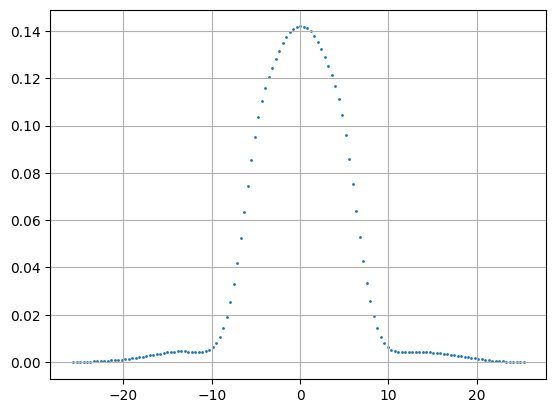

In [ ]:
plt.scatter(xy[:, 0].cpu().detach(), u[:, 0].detach().numpy(), s=1)
plt.grid()

In [ ]:
RI_squared, xy_fd, u_fd = reference_device_fd.evaluate()
xy_fd = torch.from_numpy(xy_fd).to(torch.float32)
xy = torch.cat((xy_fd, device.regions(xy_fd, format='torch')), dim=-1)
u = base_model(xy.cpu())
u = u/torch.linalg.norm(u, dim=0, keepdims=True)
print(np.sqrt(RI_squared))

[3.43667864]


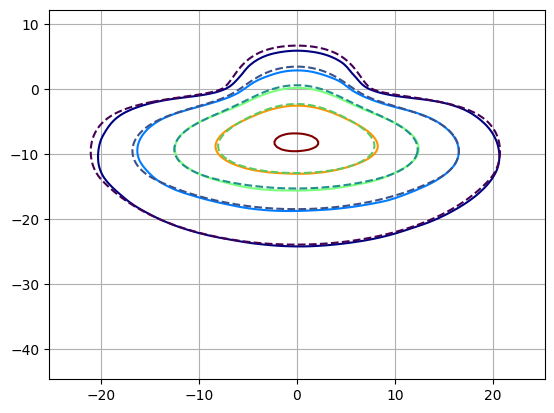

In [ ]:
levels = np.linspace(np.min(u_fd), np.max(u_fd), 6)[1:]
plt.tricontour(xy[:, 0].cpu().detach(), xy[:, 1].detach().cpu(), u[:,0].detach(), levels=levels, cmap='jet')
plt.tricontour(xy_fd[:, 0], xy_fd[:, 1], u_fd[:,0], linestyles='dashed', levels=levels)
plt.grid()